# Experiment No. 8

## Title
**To implement the Liang–Barsky Line Clipping Algorithm for clipping a line within a rectangular window**

## Objective
To clip a line segment using the Liang–Barsky algorithm and display only the visible portion inside a rectangular clipping window.

## Theory
The Liang–Barsky Line Clipping Algorithm is an efficient line clipping algorithm used in computer graphics. It uses the parametric form of a line to determine the visible part of the line inside a clipping window.

For a line from $(x_1, y_1)$ to $(x_2, y_2)$, the parametric equation is:

$$
x = x_1 + u(x_2 - x_1)
$$

$$
y = y_1 + u(y_2 - y_1)
$$

where:

$$
0 \leq u \leq 1
$$

Let:

$$
dx = x_2 - x_1
$$

$$
dy = y_2 - y_1
$$

The clipping conditions are represented using:

$$
p = [-dx,\; dx,\; -dy,\; dy]
$$

$$
q = [x_1 - x_{min},\; x_{max} - x_1,\; y_1 - y_{min},\; y_{max} - y_1]
$$

The algorithm calculates two parameters $u_1$ and $u_2$:

- $u_1$ represents the entering point
- $u_2$ represents the leaving point

If $u_1 \leq u_2$, the clipped line is accepted; otherwise, it is rejected.

## Procedure
1. Define the clipping window boundaries $(x_{min}, y_{min})$ and $(x_{max}, y_{max})$.
2. Input the endpoints of the line.
3. Calculate $dx$ and $dy$.
4. Initialize $u_1 = 0$ and $u_2 = 1$.
5. Calculate arrays $p$ and $q$.
6. For each boundary, calculate $r = q / p$.
7. Update $u_1$ for entering boundaries and $u_2$ for leaving boundaries.
8. If $u_1 \leq u_2$, calculate the clipped line endpoints.
9. Plot the original line, clipped line, and clipping window.
10. Save the output image.

## Output
- Original line
- Clipped line inside the rectangular window
- Clipping window displayed
- Output image saved as `Exp8_Output.png`

## Result and Discussion
The Liang–Barsky algorithm successfully clipped the given line using parametric equations. It efficiently calculated the entering and leaving points of the line with respect to the clipping window. Compared to Cohen–Sutherland, this method requires fewer intersection calculations and is generally more efficient.

Clipped Coordinates: [(4.0, 3.5), (8.666666666666668, 7.0)]


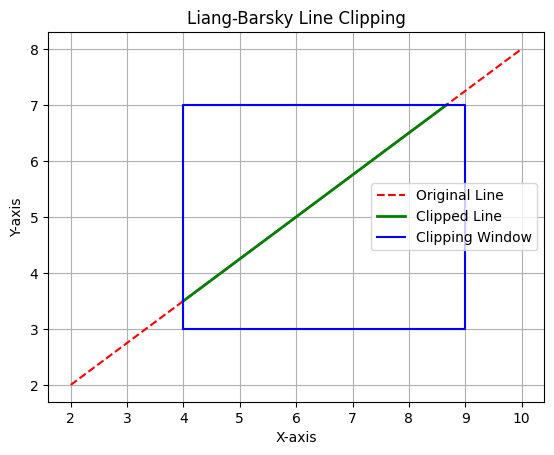

In [1]:
import matplotlib.pyplot as plt

def liang_barsky(x1, y1, x2, y2, xmin, ymin, xmax, ymax):
    dx = x2 - x1
    dy = y2 - y1

    p = [-dx, dx, -dy, dy]
    q = [x1 - xmin, xmax - x1, y1 - ymin, ymax - y1]

    u1 = 0
    u2 = 1

    for i in range(4):
        if p[i] == 0:
            if q[i] < 0:
                return False, None
        else:
            r = q[i] / p[i]

            if p[i] < 0:
                u1 = max(u1, r)
            else:
                u2 = min(u2, r)

    if u1 > u2:
        return False, None

    clipped_x1 = x1 + u1 * dx
    clipped_y1 = y1 + u1 * dy
    clipped_x2 = x1 + u2 * dx
    clipped_y2 = y1 + u2 * dy

    return True, (clipped_x1, clipped_y1, clipped_x2, clipped_y2)


# Example input
x1, y1 = 2, 2
x2, y2 = 10, 8

xmin, ymin = 4, 3
xmax, ymax = 9, 7

accepted, clipped_line = liang_barsky(x1, y1, x2, y2, xmin, ymin, xmax, ymax)

plt.plot([x1, x2], [y1, y2], "r--", label="Original Line")

if accepted:
    cx1, cy1, cx2, cy2 = clipped_line
    print("Clipped Coordinates:", [(cx1, cy1), (cx2, cy2)])
    plt.plot([cx1, cx2], [cy1, cy2], "g", linewidth=2, label="Clipped Line")
else:
    print("Line is completely outside the clipping window.")

plt.plot(
    [xmin, xmax, xmax, xmin, xmin],
    [ymin, ymin, ymax, ymax, ymin],
    "b",
    label="Clipping Window"
)

plt.title("Liang-Barsky Line Clipping")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.grid(True)
plt.legend()
plt.savefig("Exp8_Output.png")
plt.show()